<a href="https://colab.research.google.com/github/eshghinezhad/ML-Probabilistic-and-Graphical-Models_Lung-related-illnesses/blob/master/V2_lung_Related_Illnesses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # **Assignment #3  ,  Probabilistic and Graphical Models**


---


 >   ### **Monireh Eshghinezhad**  

---



#### **1. Construct a Bayes Net** in pgmpy corresponding to the given situation. Provide output of:
> #### **a.** CPTs for your net.
> #### **b.** A graphviz depiction of your net (using ‘dot’ as the ‘prog’ setting).

In [ ]:
!pip install pgmpy
import pandas as pd
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.estimators import MaximumLikelihoodEstimator

## **Define the network structure.**


In [ ]:
illness_model = DiscreteBayesianNetwork([
    ("Flu", "Fever"),  ("Flu", "Cough"),
    ("Pneumonia", "Fever"), ("Pneumonia", "Cough"),  ("Pneumonia", "ShortB"),
    ("Pneumonia", "LowOxy"), ("Pneumonia", "XRay"),
    ("Smoking", "LungCancer"), ("Radon", "LungCancer"),
    ("LungCancer", "Cough"), ("LungCancer", "ShortB"),
    ("LungCancer", "LowOxy"),("LungCancer", "XRay"),
])

> # **1-a. Define the Conditional Probability Distributions (CPDs).**

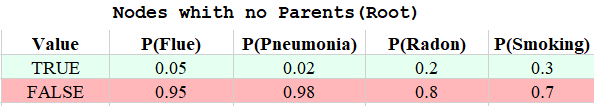

In [ ]:
# - Nodes whith no Parents(Root)
cpd_flu = TabularCPD("Flu",variable_card=2, values=[[0.95], [0.05]])
cpd_pneumonia = TabularCPD("Pneumonia", variable_card=2, values=[[0.98], [0.02]])
cpd_radon = TabularCPD("Radon", variable_card=2, values=[[0.80], [0.20]])
cpd_smoking = TabularCPD("Smoking", variable_card=2, values=[[0.70], [0.30]])
print(cpd_flu)
print(cpd_pneumonia)
print(cpd_radon)
print(cpd_smoking)




---


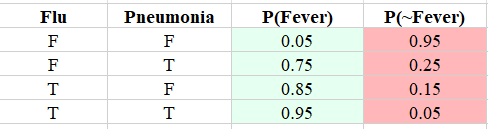

In [ ]:
# Flu, Pneumonia -->  parents of Fever
cpd_fever = TabularCPD("Fever", variable_card=2,
    values=
    [[0.95, 0.25, 0.15, 0.05],   # P(Fever=F | Flu, Pneumonia):(¬F¬P, ¬FP, F¬P, FP)
     [0.05, 0.75, 0.85, 0.95]],  # P(Fever=T | Flu, Pneumonia):(¬F¬P, ¬FP, F¬P, FP)
    evidence=["Flu", "Pneumonia"],
    evidence_card=[2, 2])
print(cpd_fever)


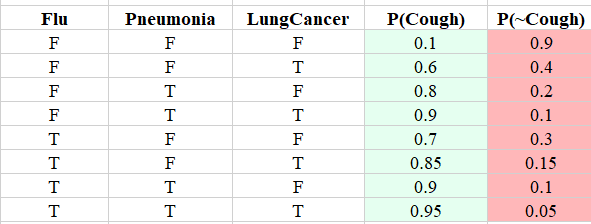

In [ ]:
# Flu, Pneumonia, LungCancer --> parents of Cough
cpd_cough = TabularCPD("Cough", variable_card=2,
    values=
    [[0.90, 0.40, 0.20, 0.10, 0.30, 0.15, 0.10, 0.05], # P(Cough=F | Flu, Pneumonia, LungCancer)
     [0.10, 0.60, 0.80, 0.90, 0.70, 0.85, 0.90, 0.95]],# P(Cough=T | Flu, Pneumonia, LungCancer)
    evidence=["Flu", "Pneumonia", "LungCancer"],
    evidence_card=[2, 2, 2])


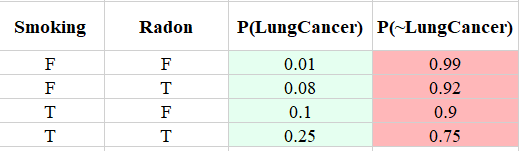

In [ ]:
# Smoking, Radon -->  parents of Lung Cancer
cpd_lungCancer = TabularCPD("LungCancer", variable_card=2,
    values=
    [[0.99, 0.92, 0.90, 0.75], # P(LungCancer=F | Flu, Radon)
     [0.01, 0.08, 0.10, 0.25]],# P(LungCancer=T | Flu, Radon)
    evidence=["Smoking", "Radon"],
    evidence_card=[2, 2])

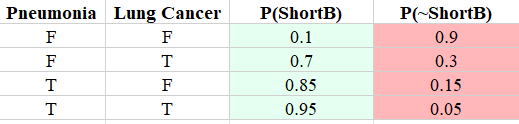

In [ ]:
# Pneumonia, LungCancer --> parents of Shortness of Breath
cpd_shortB = TabularCPD("ShortB", variable_card=2,
    values=
    [[0.90, 0.30, 0.15, 0.05], # P(ShortB=F | Pneumonia, LungCancer)
     [0.10, 0.70, 0.85, 0.95]],# P(ShortB=T | Pneumonia, LungCancer)
    evidence=["Pneumonia", "LungCancer"],
    evidence_card=[2, 2])
print(cpd_shortB)

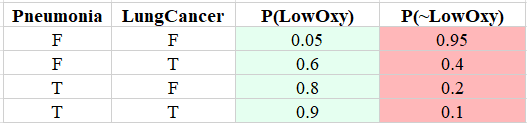

In [ ]:
# Pneumonia, LungCancer --> parents of Low Oxygen
cpd_lowOxy = TabularCPD("LowOxy", variable_card=2,
    values=
    [[0.95, 0.40, 0.20, 0.10], # P(LowOxy=F | Pneumonia, LungCancer)
     [0.05, 0.60, 0.80, 0.90]],# P(LowOxy=T | Pneumonia, LungCancer)
    evidence=["Pneumonia", "LungCancer"],
    evidence_card=[2, 2])
print(cpd_lowOxy)

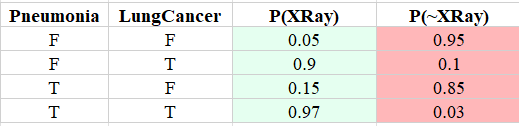

In [ ]:
# Pneumonia, LungCancer --> parents of positive chest X-Ray
cpd_XRay = TabularCPD("XRay", variable_card=2,
    values=
    [[0.95, 0.10, 0.85, 0.03], # P(XRay=F | Pneumonia, LungCancer)
     [0.05, 0.90, 0.15, 0.97]],# P(XRay=T | Pneumonia, LungCancer)
    evidence=["Pneumonia", "LungCancer"],
    evidence_card=[2, 2])
print(cpd_XRay)

> ## **Add the CPDs to the model.**

In [ ]:
illness_model.add_cpds(cpd_flu, cpd_pneumonia, cpd_radon, cpd_smoking, cpd_fever,
                       cpd_cough, cpd_lungCancer, cpd_shortB, cpd_lowOxy, cpd_XRay)

> ## **Check if the model is correctly defined.**

In [ ]:
print("Model valid:", illness_model.check_model())



> # **1-b. Visualizing the Network**


In [ ]:
!apt-get install -y graphviz graphviz-dev
!pip install pygraphviz

from IPython.display import Image
viz = illness_model.to_graphviz()

viz.draw('illness_model.png', prog='dot')
Image('illness_model.png')


---
---
### **2. Use variable elimination** to compute the following (ensure each is labelled clearly):
> #### **a.** The probability of having flu, given cough, and the probability of having flu, given
shortness of breath. Do these results make sense? Briefly explain.
> #### **b.** The probability of having a positive x-ray, given smoking and radon.


---



> # **2-a. P(Flu | Cough) and P(Flu | ShortB):**

In [ ]:
from pgmpy.inference import VariableElimination
infer = VariableElimination(illness_model)
flu_cough = infer.query(
    variables=["Flu"],
    evidence={"Cough": 1}
)
print("P(Flu given Cough=True):")
print(flu_cough)
#---------------------------------------
flu_shortB = infer.query(
    variables=["Flu"],
    evidence={"ShortB": 1}
)
print("\n P(Flu given Shortness of Breath=True):")
print(flu_shortB)

> ## **Explaination of the Results:**
### Prior P(Flu=True) = 0.05 --> (only 5% of people suffer from flu)
### P( Flu = True | Cough ) = 0.21 ____ P( Flu = True | ShortB )   = 0.05
### **The results make sense** --> knowing Shortness of Breath gives no information about Flu.
### Cough IS a **direct** symptom of Flu (no active path). So observing a cough gives us evidence that Flu is more likely --> **21%** in this model : cough is good evidence for flu
### But Shortness of breath is conditionally independent of Flu in the network structure, so observing it does not update the probability of Flu. --> **5%** equal to prior, since flu has no edge to ShortB

> # **2-b. P(XRay | Smoking, Radon):**

In [ ]:
xray_smoking_radon = infer.query(
    variables=["XRay"],
    evidence={"Smoking": 1, "Radon": 1}
)
print("P(XRay given Smoking=True, Radon=True):")
print(xray_smoking_radon)

> ## **Explaination of the Results:**
### Baseline P(XRay=positive) with no evidence  = 0.05
### P(XRay=positive | Smoking=True, Radon=True) = 0.26
### The results show that P(XRay=positive) is **so much higher** when Smoking and Radon are both True. There is a chain of reasoning behind these:
### we khnow that with both smoking and Radon, the probability of lung cancer is 25% and also when LungCancer=True --> P(XRay=positive)   = 0.90
### Even though XRay is not directly connected to Smoking or Radon but there is a **path** between them **Through LungCancer**.


---

---


### **3.** Suppose that we have a patient who has both a cough and shortness of breath. We are trying to **compare the relative probabilities of pneumonia and lung cancer.**
> #### **a.** What are the probabilities of each in this situation?
> #### **b.** What is the value of an x-ray, in clarifying the situation? Be very specific.
> #### **c.** Consider trying to answer the above questions using ‘conventional’ machine learning models. Explain the process that would be necessary to answer the questions above using models of this type, and contrast it to the method used here.

> # **3-a. P(pneumonia | Cough , ShortB) -  P(LungCancer | Cough , ShortB)**

In [ ]:
pneumonia_c_s = infer.query(
    variables=["Pneumonia"],
    evidence={"Cough": 1, "ShortB": 1}
)
print("\n P(Pneumonia | Cough, ShortB):")
print(pneumonia_c_s)


lungCancer_c_s = infer.query(
    variables=["LungCancer"],
    evidence={"Cough": 1, "ShortB": 1}
)
print("\n P(Lung Cancer | Cough, ShortB):")
print(lungCancer_c_s)

> ## **Explaination of the Results:**
###   Both diseases became much more probable after observing Cough + ShortB.
### Base rate of P(**Pneumonia** =positive)  = **0.02**
### `After observing Cough + ShortB` --> **0.28**
  =====================================================
### Base rate of P(**LungCancer** =positive)  = **0.055**
### `After observing Cough + ShortB` --> **0.49**
> ###   LungCancer is currently MORE likely than Pneumonia because: 0.49 > 0.28
>  ### - Both Cough AND ShortB together point strongly toward LungCancer, because ShortB is only caused by Pneumonia and LungCancer in our model, and Lung cancer becomes more likely not only because of its higher prior, but because the combination of cough and shortness of breath is more strongly associated with lung cancer in the CPTs.
>  ### - But we are **NOT certain** — **Both diseases are possible**
  
###  The doctor needs more information to distinguish them --> This is where an X-Ray becomes valuable

> # **3-b. Adding XRay result as extra evidence**

In [ ]:
# Concidering ‘Positive’ chest x-ray
pneumonia_positivXRay = infer.query(
    variables=["Pneumonia"],
    evidence={"Cough": 1, "ShortB": 1, "XRay": 1}
)
print("\n P(Pneumonia | Cough, ShortB,  PositiveXRay):")
print(pneumonia_positivXRay)

lungCancer_positivXRay = infer.query(
    variables=["LungCancer"],
    evidence={"Cough": 1, "ShortB": 1, "XRay": 1}
)
print("\n P(lungCancer | Cough, ShortB,  PositiveXRay):")
print(lungCancer_positivXRay)



In [ ]:
# Concidering ‘Negative’ chest x-ray
pneumonia_negativeXRay = infer.query(
    variables=["Pneumonia"],
    evidence={"Cough": 1, "ShortB": 1, "XRay": 0}
)
print("\n P(Pneumonia | Cough, ShortB,  negativeXRay):")
print(pneumonia_negativeXRay)

lungCancer_negativeXRay = infer.query(
    variables=["LungCancer"],
    evidence={"Cough": 1, "ShortB": 1, "XRay": 0}
)
print("\n P(lungCancer | Cough, ShortB,  negativeXRay):")
print(lungCancer_negativeXRay)

> ## **Explaination of the Results:**


> ### **X-Ray is really valuable for distinguishing between LungCancer and Pneumonia**
> ### **Resolves uncertainty between competing causes**
### **POSITIVE X-Ray result:**
###    - `LungCancer` **jumps** from 0.49 --> **0.90**
###    - `Pneumonia` drops from 0.28 -->  0.12
###    - The doctor should treat **`positive` result of chest x-ray** as a **strong `cancer` indicator**

### **NEGATIVE X-Ray result:**
###  - Pneumonia becomes MORE likely because
###  - `Pneumonia` **jumps** from 0.28 --> **0.44**
###  - `LungCancer` drops sharply from 0.49 --> 0.1
###  -  So **`negative` result of chest x-ray** is strong evidence **against cancer**
###  - The doctor should treat this as a **strong `Pneumonia` indicator**

### **CONCLUSION:**
###  The **`X-Ray is extremely informative`** in this situation. It can shift the diagnosis dramatically in either direction:
### This large change in probability is what makes the X-Ray a high-value diagnostic test here. Before the X-Ray, the doctor faces almost a 50/50 situation for LungCancer. After the X-Ray, the situation becomes much clearer in either direction.



> # **3-c. Comparison of using Conventional Ml models and Baysian Network**

**CONVENTIONAL ML APPROACH:**
  - Requires a **separate** model for each query: ( much more expensive,
  slow, and inflexible)
      * Model A: predict LungCancer given {Cough, ShortB}
      * Model B: predict Pneumonia  given {Cough, ShortB}
      * Model C: predict LungCancer given {Cough, ShortB, XRay}
  - Needs a large **labelled dataset**
  - Cannot handle missing evidence
  - Cannot reason backwards (symptoms --> causes)
  - Black box — hard for doctors to interpret

**BAYES NET APPROACH:**
  - **ONE model** answers ALL queries in ANY direction
  - Works with **missing** or partial evidence naturally
  - Can be built from expert knowledge (no data needed)
  - Transparent and interpretable
  - Handles **rare** diseases well

----------------------------------------------------------------
SUMMARY TABLE
----------------------------------------------------------------

  Feature                   | Conventional ML | Bayes Net
  --------------------------|-----------------|----------
  Queries supported         | One per model   | Unlimited
  Direction of reasoning    | One way only    | Any direction
  Missing evidence handling | Cannot handle   | Handled naturally
  Causal reasoning          | No              | Yes
  Data requirement          | Large dataset   | Can use expert knowledge
  Interpretability          | Low (black box) | High (graph is explanation)
  Rare disease handling     | Poor            | Good
  New questions             | Retrain model   | No retraining needed


**Conclusion:**
*    For medical diagnosis, Bayes Nets are clearly better because doctors need flexible reasoning with many different combinations of symptoms and test results.(Exact probabilistic reasoning about the change in posterior given new evidence)

---

---


### **4.** Estimate the probability of lung cancer given cough and shortness of breath, using **rejection sampling**. How does your estimate **compare** to the value computed by **variable elimination**,above?

> ## **Rejection Sampling:  P(LungCancer | Cough, ShortnessOfBreath)**

In [ ]:
from pgmpy.sampling import BayesianModelSampling

sampler = BayesianModelSampling(illness_model)

#  Generate 100,000 random samples from the model
samples = sampler.forward_sample(size=100000)

#  REJECT samples that don't match: Keep only rows where Cough=1 & ShortB=1
accepted = samples[
    (samples["Cough"]  == 1) &
    (samples["ShortB"] == 1)
]
num_accepted = len(accepted)
print (f"From   10000  generated samples only   {num_accepted}  have cough and shortness of breath")

#  Count how many of accepted samples have LungCancer=True

LungCancer_true   = (accepted["LungCancer"] == 1).sum()
print (f"From  {num_accepted}  accepted samples only   {LungCancer_true}  have lung cancer")
estimate_prob = LungCancer_true / num_accepted

> ## **Comparing by Variable Elimination**

In [ ]:
print(f"\n  Exact Answer from Variable Elimination : P(Lung Cancer | Cough, shortness of breath):  {lungCancer_c_s.values[1]:.4f}")
print(f"  Estimate Probability from Rejection Sampling : {estimate_prob:.4f}")

> ## **Explaination of the Results:**
### The rejection sampling estimate is very close to the exact variable elimination answer (~0.49). There is **`slightly different`** in each run.
### Difference is very small (~0.001 to 0.005).
### The small difference exists because `sampling is approximate`, it introduces random noise. The more samples we generate, the more accurate the estimate becomes.

### **Limitation--> Rejection Sampling is inefficient:**
### Out of 10,000 samples, about 5,000 are kept. The other 9,500 are thrown away (wasted work). This happens because
> ###  `Cough=True` and `ShortB=Tru`e together is **not** that **common** in the population.
### When **evidence is very rare**, almost all samples get **rejected** and the method becomes very slow.

---

---




### **5.** Using rejection sampling, generate 10000 samples where lung cancer is true, and all of short of breath, cough, and x-ray are false. What happens here, and why?

> ## **Rejection Sampling:  P(LungCancer | ¬Cough, ¬ShortnessOfBreath, ¬XRay )**

In [ ]:
#  Generate 10,000 random samples from the model
samples = sampler.forward_sample(size=10000)

#Keep only samples matching ALL conditions
#         LungCancer=True, ShortB=False, Cough=False, XRay=False
accepted = samples[
    (samples["LungCancer"] == 1) &
    (samples["ShortB"]     == 0) &
    (samples["Cough"]      == 0) &
    (samples["XRay"]       == 0)
]

num_accepted = len(accepted)
print (f"From   10000  generated samples only   {num_accepted}  have no cough and no shortness of breath and no positive XRay")
percent= num_accepted/10000
print (f"This is extremely close to ZERO: {percent} % --> rare evidence ")

> ## **Explaination of the Results:**
### lung Cancer with **none** of its **symptoms** is theoretically possible but **extremely rare**.

### Why is this combination so rare?
### To get ALL of these conditions true at the same time:

 -  P(LungCancer = True)          ≈ 0.055
 -  P(Cough  = False | lungCancer = True) = 0.40
 -  P(ShortB = False | lungCancer = True) = 0.30
 -  P(XRay   = False | lungCancer = True) = 0.10

###  Joint probability ≈ 0.055 × 0.40 × 0.30 × 0.10 ≈ 0.00066
### This illustrates the **fundamental limitation** of rejection sampling: it becomes extremely inefficient when the **evidence** has very **low probability** under the model. For **rare evidence** combinations, likelihood-weighted sampling is  more practical.

---


### **6.** **Fit** your model to the **dataset** provided. Output all CPTs. What significant **differences** do you observe between the fitted model, and the original constructed model?

In [ ]:
# Load dataset and rename columns
df = pd.read_csv("ass3data.csv")
df = df.rename(columns={
    "Sm": "Smoking",
    "LC": "LungCancer",
    "R":  "Radon",
    "Fl": "Flu",
    "F":  "Fever",
    "Pn": "Pneumonia",
    "Co": "Cough",
    "SB": "ShortB",
    "X":  "XRay",
    "Ox": "LowOxy"
})
df = df.drop(columns=["Unnamed: 0"])

print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))

In [ ]:
fitModel = DiscreteBayesianNetwork([
    ("Flu", "Fever"), ("Flu", "Cough"),
    ("Pneumonia", "Fever"), ("Pneumonia", "Cough"),
    ("Pneumonia", "ShortB"), ("Pneumonia", "LowOxy"),
    ("Pneumonia", "XRay"),
    ("Smoking", "LungCancer"), ("Radon", "LungCancer"),
    ("LungCancer", "Cough"), ("LungCancer", "ShortB"),
    ("LungCancer", "LowOxy"), ("LungCancer", "XRay"),
])

#Fit CPTs and check validation
fitModel.fit(df,estimator=MaximumLikelihoodEstimator)
print("\nIs Fited Model with new dataset valid:", fitModel.check_model())

#Print all CPTs
for item in fitModel.cpds:
    print(item)


In [ ]:
flu = fitModel.get_cpds("Flu")
pn  = fitModel.get_cpds("Pneumonia")
sm  = fitModel.get_cpds("Smoking")
r   = fitModel.get_cpds("Radon")
lc  = fitModel.get_cpds("LungCancer")
sh  = fitModel.get_cpds("ShortB")
lo  = fitModel.get_cpds("LowOxy")
xr  = fitModel.get_cpds("XRay")

In [ ]:
#Comparison of Root Nodes

print("\n  Variable | Original | Fitted   | Difference ")
print("===========+==================================")
print(f"  Flu      | 0.0500   | {flu.values[1]:.4f}   | {flu.values[1]-0.0500:+.4f}")
print(f"  Pneumonia| 0.0200   | {pn.values[1]:.4f}   | {pn.values[1]-0.0200:+.4f}")
print(f"  Smoking  | 0.3000   | {sm.values[1]:.4f}   | {sm.values[1]-0.3000:+.4f}")
print(f"  Radon    | 0.2000   | {r.values[1]:.4f}   | {r.values[1]-0.2000:+.4f}")

### **ROOT NODES — very close to original**:
###  Flu, Pneumonia, Smoking, Radon all **match closely**. This confirms the dataset was generated from similar base rate probabilities.

In [ ]:
#Comparison of LungCancer
print("\n                Lung Cancer")
print("\n  Sm | Radon | Original | Fitted   | Difference")
print("=================================================")
rows_lc = [
    ("F", "F", 0.010, lc.values[1][0][0]),
    ("F", "T", 0.080, lc.values[1][0][1]),
    ("T", "F", 0.100, lc.values[1][1][0]),
    ("T", "T", 0.250, lc.values[1][1][1]),
]
for sm_val, r_val, orig, fit in rows_lc:
    print(f"  {sm_val}  |   {r_val}   |  {orig:.3f}   |  {fit:.3f}   |  {fit-orig:+.3f}")


### **LUNG CANCER CPT — Fitted values are `LOWER` than Original Model:**
###  Original P(LC=T|smoking=T,radon=T) = 0.250
###  Fitted   P(LC=T|smoking=T,radon=T) = 0.054
###  The dataset does NOT match the assumed causal strength and show a much lower lung cancer rate than the scenario described.

In [ ]:
#Comparison of Shortness of Breath
print("\n           Shortness of Breath")
print("\n  Pn | LC | Original | Fitted   | Difference")
print("===============================================")
rows_sh = [
    ("F", "F", 0.100, sh.values[1][0][0]),
    ("F", "T", 0.700, sh.values[1][0][1]),
    ("T", "F", 0.850, sh.values[1][1][0]),
    ("T", "T", 0.950, sh.values[1][1][1]),
]
for pn_val, lc_val, orig, fit in rows_sh:
    print(f"  {pn_val}  | {lc_val}  |  {orig:.3f}   |  {fit:.3f}   |  {fit-orig:+.3f} ")

### **Shortness of Breath CPT - slightly different**
### LungCancer alone causes ShortB more often (0.839 vs 0.700).
### Pneumonia alone causes ShortB less often (0.709 vs 0.850).

In [ ]:
#Comparison of Low Oxygen test
print("\n           Low Oxygen Test\n")
print("  Pn | LC | Original | Fitted   | Difference")
print("===============================================")
rows_lo = [
    ("F", "F", 0.050, lo.values[1][0][0]),
    ("F", "T", 0.600, lo.values[1][0][1]),
    ("T", "F", 0.800, lo.values[1][1][0]),
    ("T", "T", 0.900, lo.values[1][1][1]),
]
for pn_val, lc_val, orig, fit in rows_lo:
    print(f"  {pn_val}  |  {lc_val} |  {orig:.3f}   |  {fit:.3f}   |  {fit-orig:+.3f}")



### **LOW OXYGEN CPT — moderate differences:**
###  Original P(LO=T|Pn=F,LC=T) = 0.600 | Fitted: 0.849
###  In the data, LungCancer alone causes low oxygen more often than the scenario assumed.

In [ ]:
#Comparison of Chest X-Ray
print("\n           Chest X-Ray\n")
print("| Pn | LC | Original | Fitted   | Difference |")
print("==============================================")
rows_xr = [
    ("F", "F", 0.050, xr.values[1][0][0]),
    ("F", "T", 0.900, xr.values[1][0][1]),
    ("T", "F", 0.150, xr.values[1][1][0]),
    ("T", "T", 0.970, xr.values[1][1][1]),
]
for pn_val, lc_val, orig, fit in rows_xr:
    print(f"  {pn_val}  |  {lc_val} |  {orig:.3f}   |  {fit:.3f}   |  {fit-orig:+.3f}")

### **X-RAY CPT — values are SWAPPED compared to original:**
###  Original P(XR=T|Pn=F,LC=T) = 0.900 | Fitted: 0.243
###  Original P(XR=T|Pn=T,LC=F) = 0.150 | Fitted: 0.909


---
## **Significant Difference**

### In the **original** model, Lung cancer shows up with a 'positive' chest x-ray 90% of the time, and Pneumonia can result in a positive x-ray 15% of the time, which shows:
> ### **positive** result of chest **x-ray** interpreted as a **strong `cancer` indicator**
###`but`
### In the **fitted data**, show the opposite: Lung cancer shows up with a 'positive' chest x-ray 24% of the time, and Pneumonia can result in a positive x-ray 90% of the time, which shows:
> ### **positive** result of chest **x-ray** interpreted as a **strong `Pneumonia` indicator**
### This means the diagnostic value of the X-Ray is interpreted very differently depending on whether we use the expert model or the fitted model.